# Stage 2A — APS Shi–Tomasi feature initialization

This experiment uses APS frames accessed through the synchronized frame-pair sequence from Stage 1B. It compares requested caps of 50, 100, 200, 300, 500, and 1,000 Shi–Tomasi corners, selected round-robin from spatial image buckets. Records use fixed-width numeric fields `[id, x, y, quality, valid]` and are suitable as feature-memory initialization input.

Feature IDs are unique monotonically assigned IDs for detection records in this experiment. They do not represent correspondence or persistent identity across frames. No feature velocity, KLT, event association, or tracking is implemented.

In [1]:
import importlib
import sys
from pathlib import Path

project_root = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "src" / "aps_features.py").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not locate the project root")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.davis_inspection import DavisConfig, load_davis
import src.frame_synchronization as frame_synchronization
frame_synchronization = importlib.reload(frame_synchronization)
import src.aps_features as aps_features
aps_features = importlib.reload(aps_features)
DEFAULT_OUTPUT_DIR = aps_features.DEFAULT_OUTPUT_DIR
REQUESTED_FEATURE_COUNTS = aps_features.REQUESTED_FEATURE_COUNTS
default_frame_indices = aps_features.default_frame_indices
get_aps_frame = aps_features.get_aps_frame
run_feature_count_experiment = aps_features.run_feature_count_experiment
save_experiment_outputs = aps_features.save_experiment_outputs

config = DavisConfig()
recording = load_davis(config)
origins_s, _ = frame_synchronization.load_timestamp_origins(recording, config)
windows = frame_synchronization.make_frame_windows(recording, origins_s)
frame_indices = default_frame_indices(len(windows) + 1, sample_count=5)
results, experiment_config = aps_features.run_feature_count_experiment(
    windows,
    frame_indices=frame_indices,
    requested_counts=REQUESTED_FEATURE_COUNTS,
    quality_level=0.01,
    min_feature_distance=5.0,
    block_size=3,
    bucket_columns=8,
    bucket_rows=6,
)
frame_lookup = {index: get_aps_frame(windows, index)[0] for index in frame_indices}
outputs = save_experiment_outputs(
    results, experiment_config, DEFAULT_OUTPUT_DIR, frame_lookup
)
print("Sampled frame indices:", frame_indices)
print("Feature counts:", REQUESTED_FEATURE_COUNTS)
for result_name, output_path in outputs.items():
    print(f"{result_name}: {output_path}")

Sampled frame indices: [0, 338, 677, 1016, 1355]
Feature counts: (50, 100, 200, 300, 500, 1000)
features: /home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/step_1_VIO/results/aps_feature_extraction/davis_shapes_6dof_features.npz
measurements: /home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/step_1_VIO/results/aps_feature_extraction/davis_shapes_6dof_measurements.csv
configuration: /home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/step_1_VIO/results/aps_feature_extraction/davis_shapes_6dof_configuration.json
overlays: /home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/step_1_VIO/results/aps_feature_extraction/davis_shapes_6dof_feature_overlays.png
spatial_buckets: /home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/step_1_VIO/results/aps_feature_extraction/davis_shapes_6dof_spatial_buckets.png
comparison: /home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/step_1_VIO/results/aps_feature_extractio

In [2]:
import numpy as np

print("cap | detected mean | bucket coverage mean | normalized entropy mean | median quality mean")
for count in REQUESTED_FEATURE_COUNTS:
    subset = [r for r in results if r.requested_count == count]
    print(
        f"{count:4d} | "
        f"{np.mean([r.metrics['detected_count'] for r in subset]):13.1f} | "
        f"{np.mean([r.metrics['bucket_coverage_percent'] for r in subset]):20.1f}% | "
        f"{np.mean([r.metrics['normalized_bucket_entropy'] for r in subset]):23.3f} | "
        f"{np.mean([r.metrics['median_quality'] for r in subset]):.6g}"
    )

cap | detected mean | bucket coverage mean | normalized entropy mean | median quality mean
  50 |          50.0 |                 99.2% |                   0.993 | 0.000237805
 100 |         100.0 |                 99.2% |                   0.994 | 0.000133479
 200 |         200.0 |                 99.2% |                   0.991 | 7.07443e-05
 300 |         300.0 |                 99.2% |                   0.985 | 4.91424e-05
 500 |         500.0 |                 99.2% |                   0.969 | 2.84879e-05
1000 |         633.0 |                 99.2% |                   0.960 | 2.24664e-05


overlays


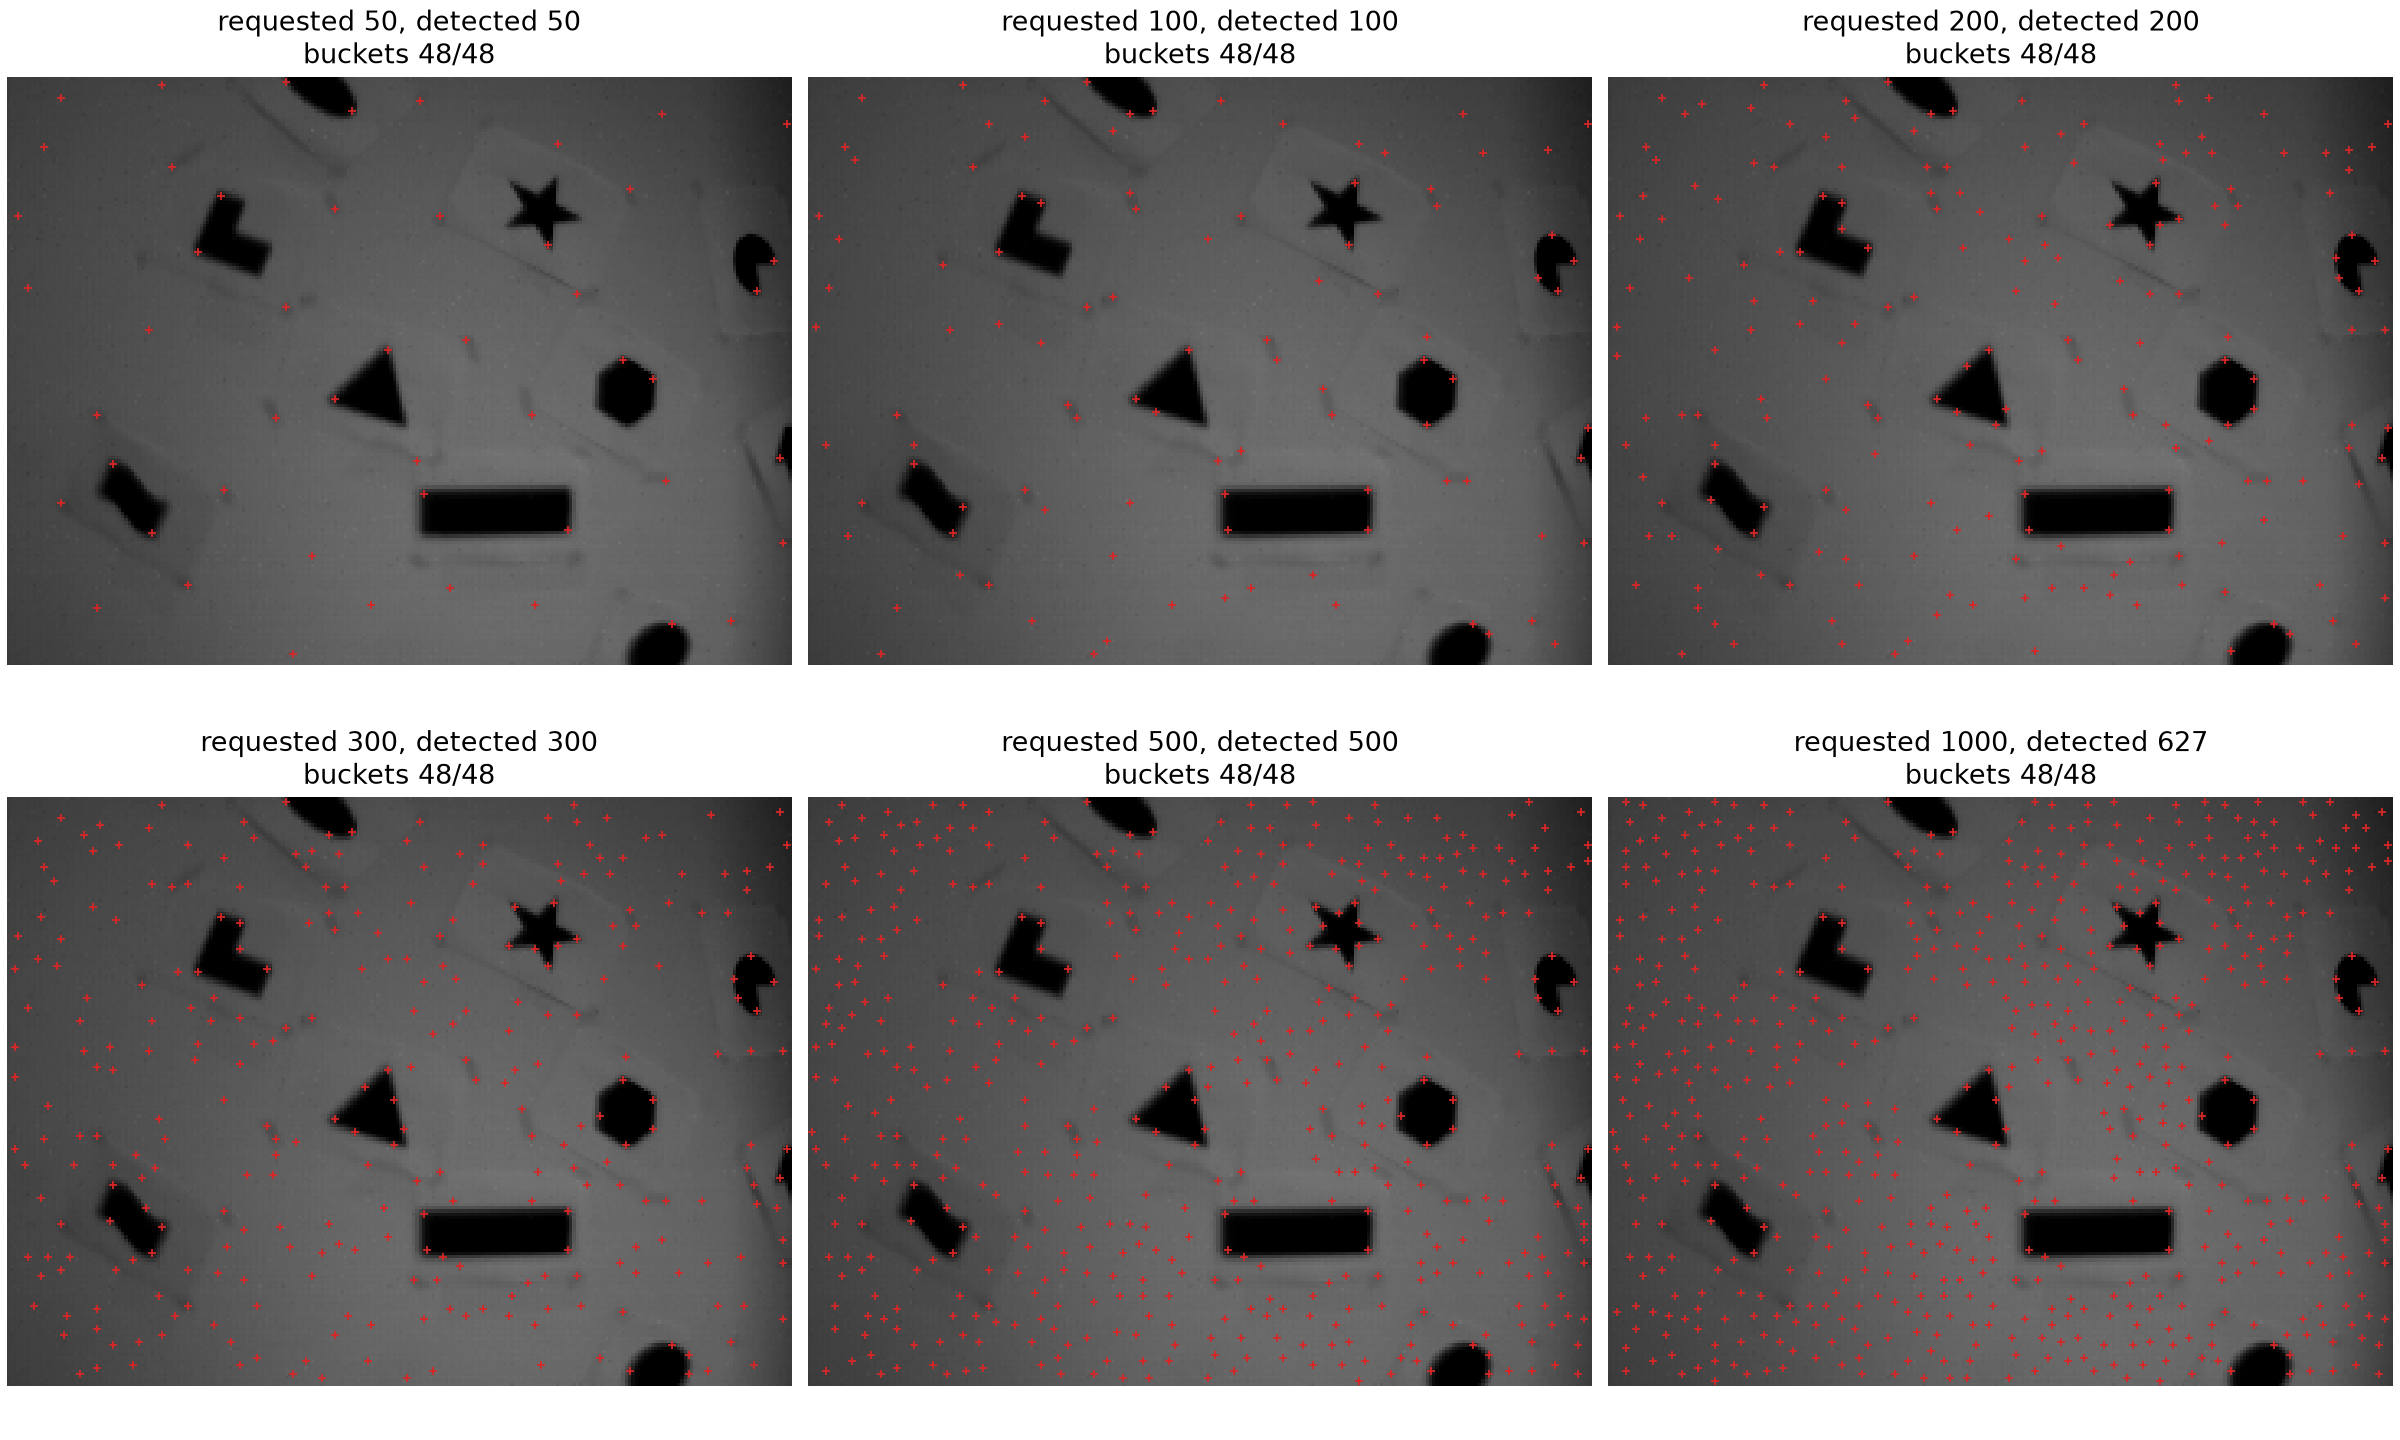

spatial_buckets


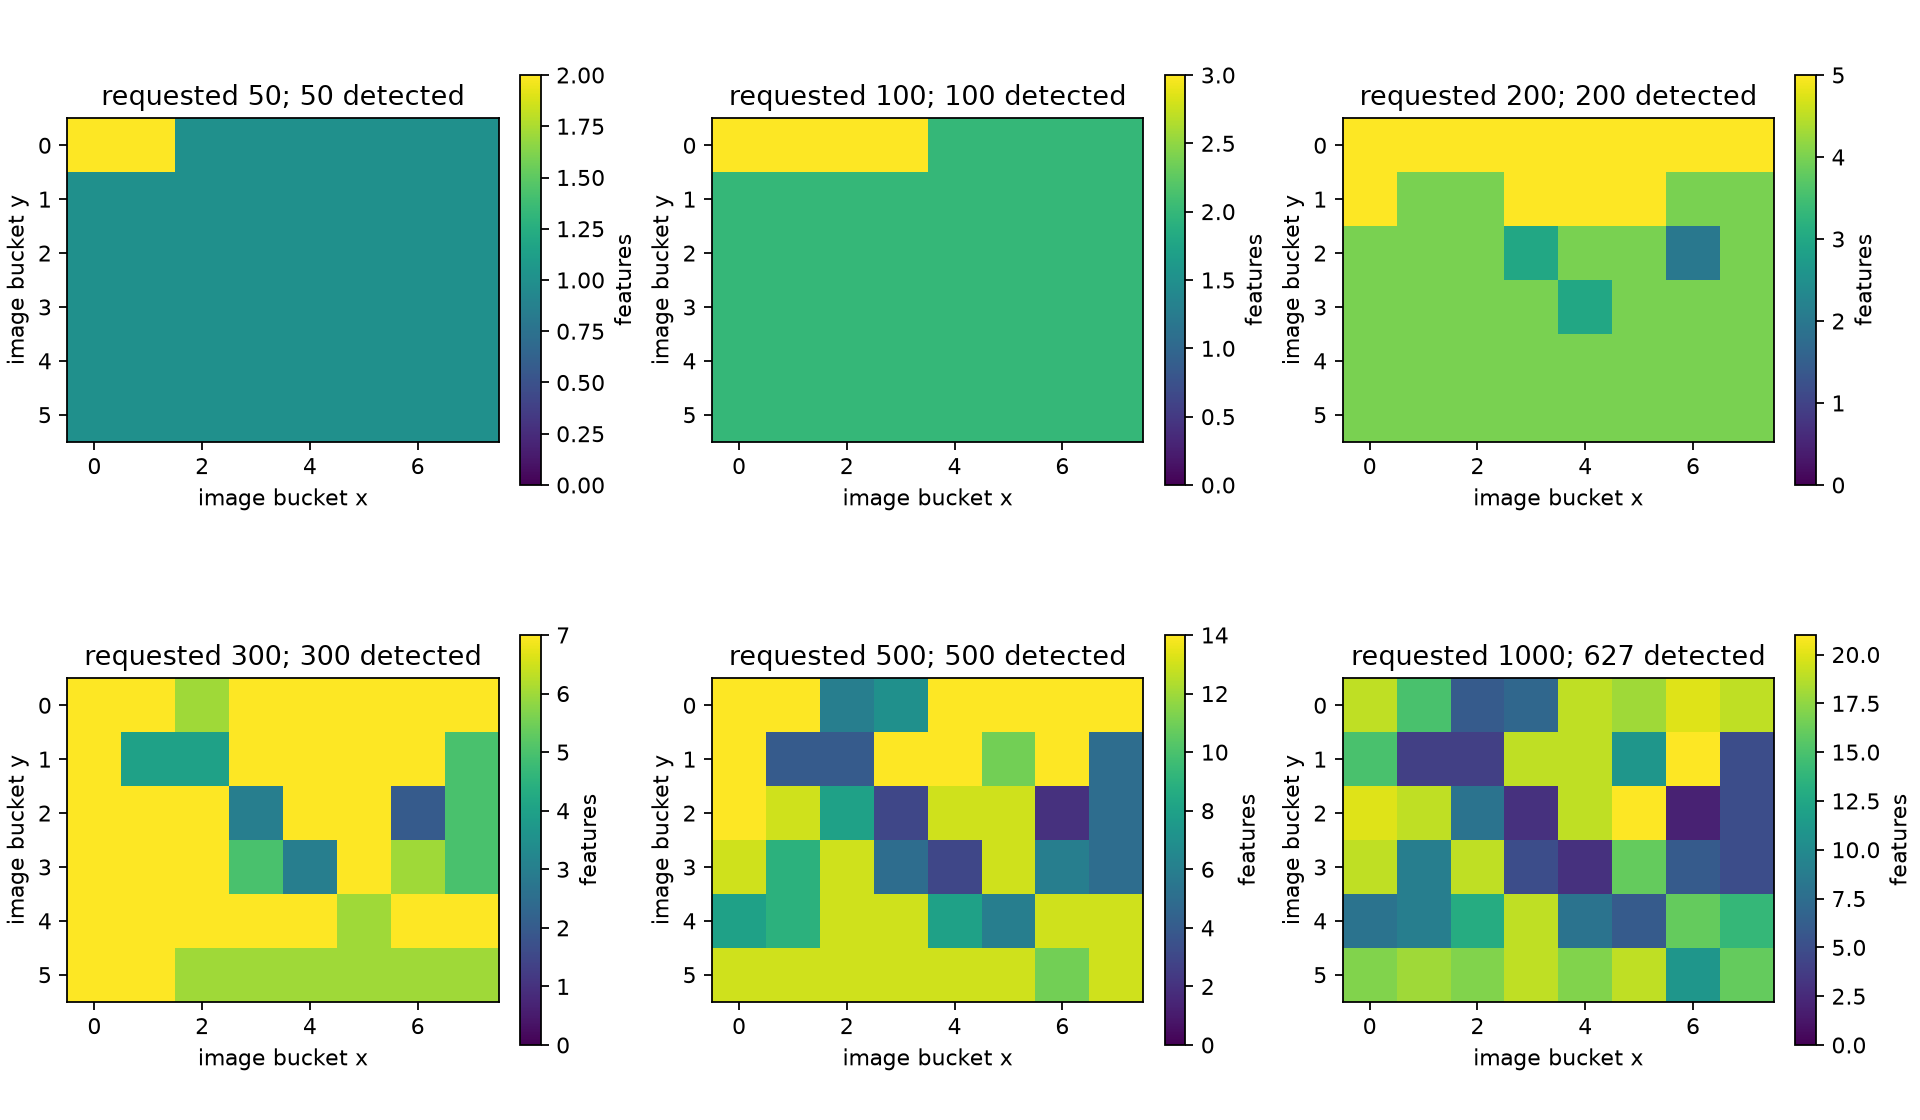

comparison


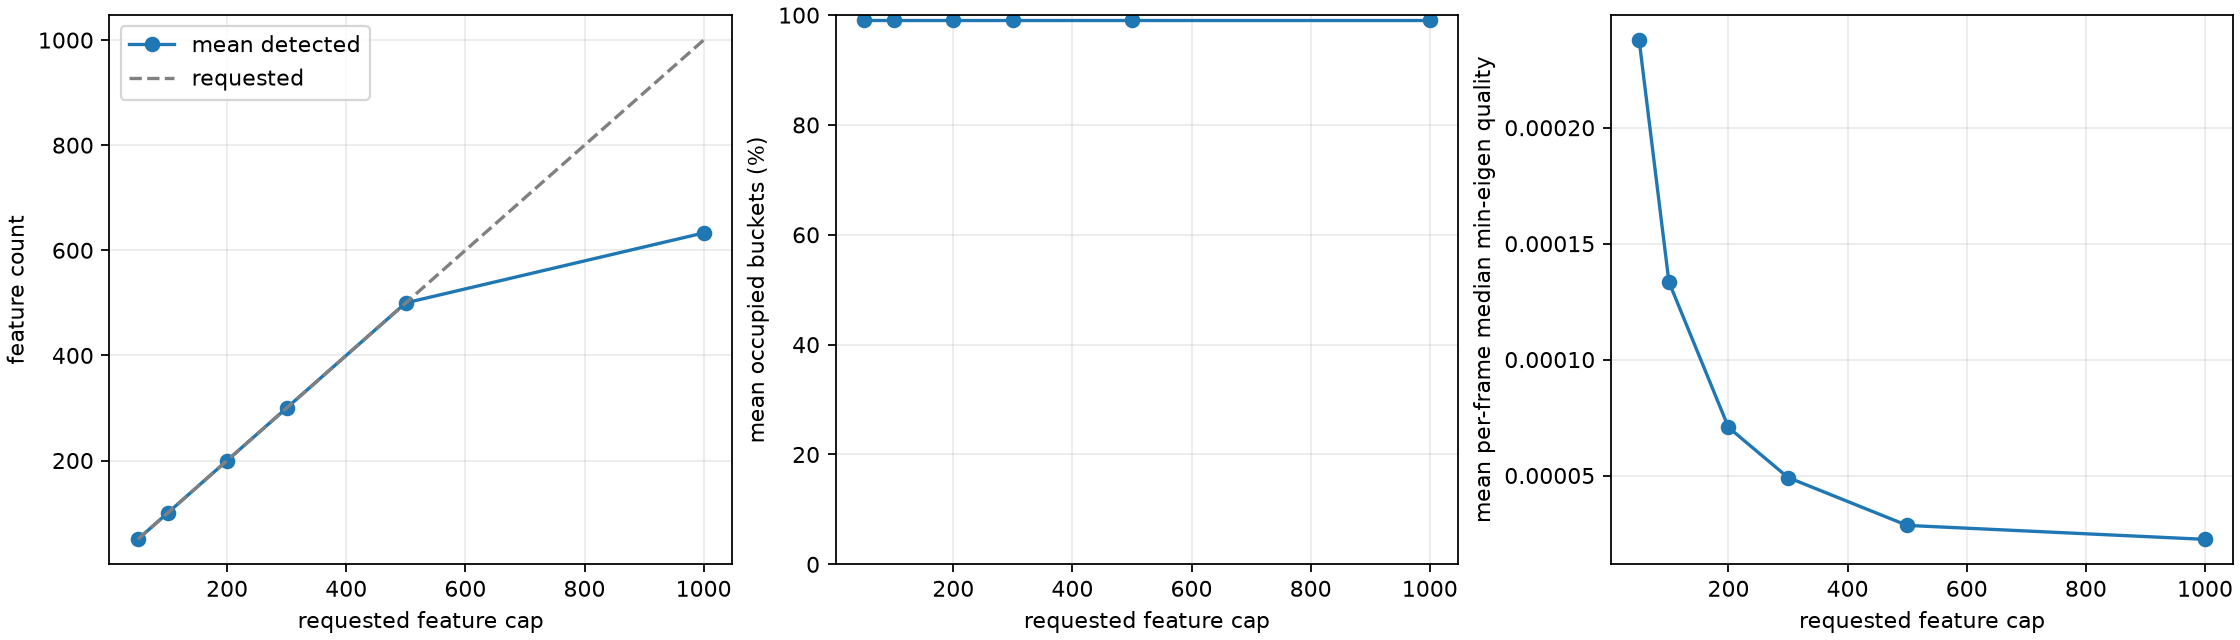

In [3]:
from IPython.display import Image, display

for key in ("overlays", "spatial_buckets", "comparison"):
    print(key)
    display(Image(filename=str(outputs[key])))

## Measurements and interpretation

The CSV reports each requested count on each sampled APS frame: detected count, count shortfall, occupied image buckets, bucket-count variation/entropy, and min-eigenvalue quality statistics. The feature archive stores only fixed-width numeric feature records and experiment selectors; it does not pickle Python objects or copy the APS image dataset.

A development recommendation is recorded in the experiment report using count attainment and spatial coverage. This is not tracking evidence: the next stage must evaluate persistence/utility before treating the recommendation as final. Stop after Stage 2A; KLT and event association are not part of this notebook.